# Linearni modeli

V okviru prejšnjih predavanj smo napovedne modele obravnavali predvsem z vidika njihovega vrednotenja in izbire, pri odločitvenih drevesih pa tudi kot način za samodejno učenje razložljivih pravil. V tem poglavju se premaknemo k modelom, kjer je napoved podana z **linearnimi kombinacijami** napovednih spremenljivk. Linearni modeli so sicer manj izrazno močni kot velika odločitvena drevesa, vendar imajo pomembno prednost: njihove parametre lahko interpretiramo kot moči vpliva posameznih spremenljivk na napoved. Poleg tega pa vrednosti parametrov izpeljemo in izračunamo neposredno iz podatkov. Skozi linearne modele bomo tudi spoznali nevronske mreže, ki jih bomo v naslednjem predavanju lahko nadgradili v bolj splošne nelinearne napovedne modele.

V okviru predavanja bomo obravnavali tri linearne modele.

1. **Linearno regresijo**, kjer numerično ciljno spremenljivko napovemo z linearno kombinacijo numeričnih napovednih spremenljivk in vrednosti koeficientov linearne kombinacije lahko izračunamo z metodo najmanjših kvadratov.
2. **Linearni perceptron za regresijo**, torej enoslojno nevronsko mrežo z enim izhodnim nevronom in linearno funkcijo aktivacije.
3. **Linearni perceptron s funkcijo aktivacije softmax**, ki uporabo enoslojno mrežo razširi na probleme klasifikacije s poljubnim številom vrednosti ciljne spremenljivke.

Prva dva modela imata enako obliko napovedi. Razlika je predvsem v jeziku, s katerim ju opišemo, in v učnih algoritmih, ki jih poudarimo. Pri linearni regresiji najprej izpeljemo neposredno formulo za koeficiente z metodo najmanjših kvadratov. Nato isto linearno funkcijo zapišemo kot enoslojno nevronsko mrežo in pokažemo, kako njene uteži učimo z gradientnim spustom. Šele po praktičnem primeru povežemo obe zgodbi in pokažemo, zakaj gradientni spust v limiti pripelje do iste rešitve kot metoda najmanjših kvadratov.

Predavanje povzema vsebino poglavja _3 Linear Regression_ in prvega dela poglavja _10 Deep Learning_ (razdelek 10.1) učbenika {cite}`james2023islrp`, ki je dostopen na naslovu [https://www.statlearning.com/](https://www.statlearning.com/).

## Linearna regresija

Naj bo
$$
S = \{\langle \boldsymbol{x}_1, y_1 \rangle, \langle \boldsymbol{x}_2, y_2 \rangle, \dots, \langle \boldsymbol{x}_n, y_n \rangle\}
$$
učna množica za nadzorovano učenje. Vsak primer ima $p$ numeričnih napovednih spremenljivk,
$$
\boldsymbol{x}_i = [x_{i1}, x_{i2}, \dots, x_{ip}]^T \in \mathbb{R}^p,
$$
ciljna spremenljivka pa je prav tako numerična, $y_i \in \mathbb{R}$.

Model linearne regresije ima obliko
$$
\hat{y}_i = m(\boldsymbol{x}_i) = \beta_0 + \sum_{j=1}^{p} \beta_j x_{ij}.
$$
Parameter $\beta_0$ je **izsek** oziroma začetna vrednost, parametri $\beta_1, \beta_2, \dots, \beta_p$ pa so smerni koeficienti, ki opisujejo vpliv posameznih napovednih spremenljivk na napoved.

Da zapis poenostavimo, vsakemu primeru dodamo umetno napovedno spremenljivko $X_0$ z vrednostjo $1$:
$$
\tilde{\boldsymbol{x}}_i = [1, x_{i1}, x_{i2}, \dots, x_{ip}]^T,
\qquad
\boldsymbol{\beta} = [\beta_0, \beta_1, \dots, \beta_p]^T.
$$
Tedaj lahko napoved zapišemo kot skalarni produkt
$$
\hat{y}_i = \tilde{\boldsymbol{x}}_i^T \boldsymbol{\beta}.
$$

Za celotno učno množico uvedemo matriko
$$
X =
\left[
\begin{array}{ccccc}
1 & x_{11} & x_{12} & \cdots & x_{1p} \\
1 & x_{21} & x_{22} & \cdots & x_{2p} \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
1 & x_{n1} & x_{n2} & \cdots & x_{np}
\end{array}
\right]
\in \mathbb{R}^{n \times (p+1)},
\qquad
\boldsymbol{y} = [y_1, y_2, \dots, y_n]^T.
$$
Vektor napovedi za vse učne primere tako zapišemo z enostavno linearno matrično formulo
$$
\hat{\boldsymbol{y}} = X \boldsymbol{\beta}.
$$

Učni algoritem bi moral iz podane učne množice primerov oceniti optimalne vrednosti parametrov $\boldsymbol{\beta}$, ki minimizirajo napako modela na učnih podatkih. En način, da izpeljemo to oceno je metoda najmanjših kvadratov.

## Metoda najmanjših kvadratov

Metoda najmanjših kvadratov predpostavi kvadratno mero napake (funkcijo izgube), ki sešteje kvadrate ostankov (angl. _residuals_), t.j., razlike med opazovano in napovedano vrednostjo ciljne spremenljivke na učni množici:
$$
\mathcal{L}(\boldsymbol{\beta}) =
\sum_{i=1}^{n} (y_i - \hat{y}_i)^2
= \sum_{i=1}^{n} (y_i - \boldsymbol{x}_i^T\boldsymbol{\beta})^2.
$$
Zgornjo enačbo lahko zapišemo v matrični obliko takole (premisli in pojasni zakaj je ta zapis ekvivalenten zgornjemu):
$$
\mathcal{L}(\boldsymbol{\beta}) =
(\boldsymbol{y} - X\boldsymbol{\beta})^T(\boldsymbol{y} - X\boldsymbol{\beta}).
$$

Učni algoritem torej v tem primeru rešuje optimizacijski problem, kjer je ciljna funkcija zgornja mera napake linearnega modela:
$$
\min_{\boldsymbol{\beta}} \mathcal{L}(\boldsymbol{\beta}).
$$
Ker je $\mathcal{L}$ kvadratna funkcija parametrov, lahko minimum poiščemo z odvajanjem. Najprej izraz razpišemo:
$$
\begin{array}{rl}
\mathcal{L}(\boldsymbol{\beta})
&= (\boldsymbol{y} - X\boldsymbol{\beta})^T(\boldsymbol{y} - X\boldsymbol{\beta}) \\
&= \boldsymbol{y}^T\boldsymbol{y}
    - \boldsymbol{y}^T X\boldsymbol{\beta}
    - \boldsymbol{\beta}^T X^T\boldsymbol{y}
    + \boldsymbol{\beta}^T X^T X\boldsymbol{\beta}.
\end{array}
$$

Izraz $\boldsymbol{y}^T X\boldsymbol{\beta}$ je skalar (tako kot so skalarji vsi štirje členi zadnjega izraza), zato je enak svojemu transponiranemu izrazu:
$$
\boldsymbol{y}^T X\boldsymbol{\beta}
= (\boldsymbol{y}^T X\boldsymbol{\beta})^T
= \boldsymbol{\beta}^T X^T\boldsymbol{y}.
$$
Zato lahko cilj poenostavimo v
$$
\mathcal{L}(\boldsymbol{\beta})
= \boldsymbol{y}^T\boldsymbol{y}
- 2\boldsymbol{y}^T X\boldsymbol{\beta}
+ \boldsymbol{\beta}^T X^T X\boldsymbol{\beta}.
$$

Odvod funkcije $\mathcal{L}\colon \mathbb{R}^{p+1} \to \mathbb{R}$ po vektorju parametrov $\boldsymbol{\beta}$ je gradient, torej vektor delnih odvodov po posameznih komponentah:
$$
\nabla_{\boldsymbol{\beta}} \mathcal{L}
= \left[
\frac{\partial \mathcal{L}}{\partial \beta_0} \;
\frac{\partial \mathcal{L}}{\partial \beta_1} \;
\dots \;
\frac{\partial \mathcal{L}}{\partial \beta_p}
\right]^T.
$$

Pri odvajanju uporabimo dve pravili matričnega odvajanja:
$$
\nabla_{\boldsymbol{\beta}}(\boldsymbol{a}^T\boldsymbol{\beta}) = \boldsymbol{a},
\qquad
\nabla_{\boldsymbol{\beta}}(\boldsymbol{\beta}^T A \boldsymbol{\beta}) = (A + A^T)\boldsymbol{\beta}.
$$
V našem primeru je $A = X^T X$ simetrična matrika (premisli zakaj), zato velja $(A + A^T)\boldsymbol{\beta} = 2X^TX\boldsymbol{\beta}$. Dobimo
$$
\nabla_{\boldsymbol{\beta}} \mathcal{L}
= -2X^T\boldsymbol{y} + 2X^T X\boldsymbol{\beta}.
$$

V minimumu ciljne funkcije napake je gradient enak nič:
$$
-2X^T\boldsymbol{y} + 2X^TX\boldsymbol{\beta} = \boldsymbol{0}.
$$
Od tod sledijo **normalne enačbe** metode najmanjših kvadratov:
$$
X^TX\boldsymbol{\beta} = X^T\boldsymbol{y}.
$$
Če je matrika $X^TX$ obrnljiva, dobimo neposredno formulo za izračun optimalnih vrednosti koeficientov linearne regresije:
$$
\boldsymbol{\beta} = (X^TX)^{-1}X^T\boldsymbol{y}.
$$

Če $X^TX$ ni obrnljiva, na primer zaradi linearno odvisnih napovednih spremenljivk, uporabimo psevdoinverz ali pa problem nekoliko spremenimo z regularizacijo. Osnovna ideja pa ostane ista: izberemo tisti vektor koeficientov, pri katerem je vsota kvadratov ostankov najmanjša.

## Geometrijska interpretacija

Za tiste, ki jim pomaga geometrijska interpretacija metod, lahko dodamo, da ima formula najmanjših kvadratov tudi lepo geometrijsko razlago. Vektor napovedi je
$$
\hat{\boldsymbol{y}} = X\boldsymbol{\beta}
= X(X^TX)^{-1}X^T\boldsymbol{y}.
$$
Matriko $H = X(X^TX)^{-1}X^T$ imenujemo **projekcijska matrika**. Vektor $\hat{\boldsymbol{y}} = H\boldsymbol{y}$ je ortogonalna projekcija vektorja opazovanih vrednosti $\boldsymbol{y}$ na prostor, ki ga razpenjajo stolpci matrike $X$.

Če upoštevamo, da so ostanki enaki 
$$
\boldsymbol{r} = \boldsymbol{y} - \hat{\boldsymbol{y}} = \boldsymbol{y} - X\boldsymbol{\beta}
$$
in pri tem upoštevamo še normalne enačbe metode najmanjših kvadratov (glej prejšnji razdelek), dobimo naslednjo formulo za vektor ostankov:
$$
\boldsymbol{0} = X^T(\boldsymbol{y} - X\boldsymbol{\beta}) = X^T\boldsymbol{r}.
$$
To pomeni, da je vektor ostankov ortogonalen na vsak stolpec matrike $X$. Linearna regresija torej ne naredi ostanke nujno ničelne, ampak jih naredi takšne, da v podatkih ne ostane več linearne smeri, ki bi jo lahko pojasnili s stolpci matrike $X$.

## Linearni perceptron za regresijo in gradientni spust

Linearni model lahko zapišemo tudi kot najpreprostejšo nevronsko mrežo imenovano perceptron. Nevronsko mrežo sestavljajo nevroni, ki so med seboj povezani z usmerjenimi povezavami, ki jih imenujemo sinapse.

Slika {ref}`fig-nevron prikazuje funkcijo nevrona. Ta preslika vhodne signale, ki pridejo iz drugih nevronov po sinapsah (puščicah na levi strani nevrona), v stanje nevrona $v \in \mathbb{R}$. Funkcija aktivacije $\phi\colon \mathbb{R} \to \mathbb{R}$ preslika stanje nevrona v njegov izhod $y = \phi(v)$, torej izhodni signal, ki ga po izhodnih sinapsah pošlje naprej povezanim nevronom.


```{figure} ../materiali/funkcija-nevrona.png
---
name: fig-nevron
---
Funcija nevrona.
```

Vsaki sinapsi pripada utež $w \in \mathbb{R}$. Tudi vsakemu nevronu pripada utež, ki jo imenujemo utež premika (angl. _bias): na sliki je utež premika označena z $w_0$. Podobno kot pri linearni regresiji, pri formulah uporabimo dodatni vhod $x_0 = 1$ za upoštevanje uteži premika. Ta trik nam omogoča, da vsote lahko pišemo v obliki skalarnega produkta in formule pišemo v matrični obliki.

Perceptron je zelo enostavna nevronska mreža, kjer so nevroni organizirani v dveh plasteh. V prvi, vhodni plasti, so vhodni nevroni, ki ustrezajo napovednim spremenljivkam. Druga plast ima en izhodni nevron, ki napove numerično vrednost ciljne spremenljivke.

Bolj formalno, če vektor uteži na sinapsah perceptrona označimo z
$$
\boldsymbol{w} = [w_0, w_1, \dots, w_p]^T,
$$
je stanje izhodnega nevrona linearna obtežena vsota vhodov:
$$
v = \boldsymbol{w}^T\boldsymbol{x} = \sum_{j=0}^{p} w_j x_j.
$$
Pri regresiji v izhodnem nevronu uporabimo linearno aktivacijsko funkcijo
$$
\phi(v) = v.
$$
Zato je izhod mreže
$$
\hat{y} = \phi(v) = v = \boldsymbol{w}^T\boldsymbol{x}.
$$

To je ista oblika napovedi vrednosti ciljne spremenljivke kot pri linearni regresiji, le da parametre zdaj imenujemo uteži, model pa beremo kot nevronsko mrežo. Namesto neposredne formule za parametre, se pri nevronskih mrežah običajno vprašamo, kako uteži postopoma spreminjati, da se funkcija izgube zmanjšuje. Temu je namenjen algoritem gradientnega spusta (angl. _gradient descent_), ki ga opišemo v nadaljevanju.

Gradientni spust je zelo preprost optimizacijski algoritem. Za iskanje minimuma ciljne funkcije najprej izberemo naključno točko iz njene domene. Nato v tej točki izračunamo vrednost gradienta in točko premaknemo v smeri negativnega gradienta, ki je hkrati smer največjega padanja ciljne funkcije. Premik točke ponavljamo toliko časa, dokler ne dosežemo (lokalni) minimum ciljne funkcije, kjer je gradient enak nič, in se tako točka ne premika več.

Ključen korak, ki ga moramo izpeljati, da uporabimo gradientni spust je torej izračun gradienta ciljne funkcije, v primeru nevronske mreže, funkcije izgube po utežeh. Za regresijski perceptron uporabimo kvadratno izgubo. Za en učni primer naj bo
$$
E = \frac{1}{2}(y - \hat{y})^2,
\qquad
\hat{y} = \phi(v),
\qquad
v = \boldsymbol{w}^T\boldsymbol{x}.
$$
Premisli zakaj faktor $\frac{1}{2}$ ne spremeni točke minimuma in zakaj je sploh koristen.

Gradient po uteži $w_j$ izpeljemo z verižnim pravilom odvajanja:
$$
\begin{array}{rl}
\frac{\partial E}{\partial w_j}
&= \frac{\partial E}{\partial \hat{y}}
   \frac{\partial \hat{y}}{\partial v}
   \frac{\partial v}{\partial w_j} \\
&= -(y - \hat{y})\,\phi'(v)\,x_j.
\end{array}
$$
Pri linearnem perceptronu je $\phi(v)=v$, zato je $\phi'(v)=1$ in dobimo še bolj poenostavljeno formulo gradienta:
$$
\frac{\partial E}{\partial w_j} = (\hat{y} - y)x_j.
$$
Tako je posodobitveno pravilo za en učni primer:
$$
\boldsymbol{w} \leftarrow \boldsymbol{w} - \eta(\hat{y} - y)\boldsymbol{x}
= \boldsymbol{w} + \eta(y - \hat{y})\boldsymbol{x},
$$
kjer je $\eta > 0$ parameter gradientnega spusta, ki ga imenujemo hitrost (ali stopnja) učenja (angl. _learning rate_).

Če gradient izračunamo na vseh primerih hkrati, dobimo paketni gradientni spust. Za celotno učno množico uporabimo povprečno kvadratno izgubo
$$
J(\boldsymbol{w}) = \frac{1}{2n}\lVert \boldsymbol{y} - X\boldsymbol{w}\rVert^2.
$$
Njen gradient je
$$
\nabla_{\boldsymbol{w}}J(\boldsymbol{w})
= \frac{1}{n}X^T(X\boldsymbol{w} - \boldsymbol{y}),
$$
zato je iteracija gradientnega spusta
$$
\boldsymbol{w}^{(t+1)}
= \boldsymbol{w}^{(t)} - \eta\frac{1}{n}X^T(X\boldsymbol{w}^{(t)} - \boldsymbol{y}).
$$

V tem razdelku je uporabljena funkcija aktivacije linearna, zato nevronska mreža še vedno predstavlja linearni model. Če linearno funkcijo zamenjamo z drugo (nelinearno) funkcijo aktivacije, na primer sigmoidno funkcijo, hiperboličnim tangensom ali funkcijo ReLU, dobimo drugačno povezavo med stanjem nevrona $v$ in izhodom $\hat{y}$. Takšne nelinearne funkcije aktivacije so ključne pri večjih nevronskih mrežah, ki omogočajo modeliranje nelinearnih odvisnosti v podatkih in jih bomo spoznali na naslednjih predavanjih.

## Primer: ena napovedna in ena ciljna spremenljivka

Poglejmo preprost primer z eno napovedno spremenljivko $X$ in eno numerično ciljno spremenljivko $Y$. Linearna regresija bo koeficiente izračunala neposredno z normalnimi enačbami metode najmanjših kvadratov. Linearni perceptron bo začel z napačno premico in jo nato z gradientnim spustom postopoma premikal proti isti rešitvi.

V tem primeru je razširjena matrika
$$
X =
\left[
\begin{array}{cc}
1 & x_1 \\
1 & x_2 \\
\vdots & \vdots \\
1 & x_n
\end{array}
\right],
$$
model pa je premica
$$
\hat{y} = \beta_0 + \beta_1x.
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

x = np.array([0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0])
y = np.array([1.2, 1.7, 2.6, 3.0, 4.1, 4.4, 5.5, 5.8])
X = np.column_stack([np.ones_like(x), x])

# Neposredna rešitev linearne regresije z normalnimi enačbami.
beta_nk = np.linalg.solve(X.T @ X, X.T @ y)

# Isti model učimo še kot linearni perceptron z gradientnim spustom.
eta = 0.05
st_iteracij = 500
utezi = np.array([-0.5, 0.0])
shranjene_iteracije = {0, 1, 5, 10, 100, 500}
zgodovina = {0: utezi.copy()}
napake = []

for iteracija in range(1, st_iteracij + 1):
    napoved = X @ utezi
    gradient = X.T @ (napoved - y) / len(y)
    utezi = utezi - eta * gradient
    napake.append(np.mean((y - X @ utezi) ** 2))

    if iteracija in shranjene_iteracije:
        zgodovina[iteracija] = utezi.copy()

utezi_perceptron = utezi
mse_nk = np.mean((y - X @ beta_nk) ** 2)
mse_perceptron = np.mean((y - X @ utezi_perceptron) ** 2)

print(f"Linearna regresija: beta_0 = {beta_nk[0]:.3f}, beta_1 = {beta_nk[1]:.3f}, MSE = {mse_nk:.4f}")
print(
    f"Linearni perceptron po {st_iteracij} iteracijah: "
    f"w_0 = {utezi_perceptron[0]:.3f}, w_1 = {utezi_perceptron[1]:.3f}, MSE = {mse_perceptron:.4f}"
)

Linearna regresija: beta_0 = 1.133, beta_1 = 0.687, MSE = 0.0277
Linearni perceptron po 500 iteracijah: w_0 = 1.132, w_1 = 0.687, MSE = 0.0277


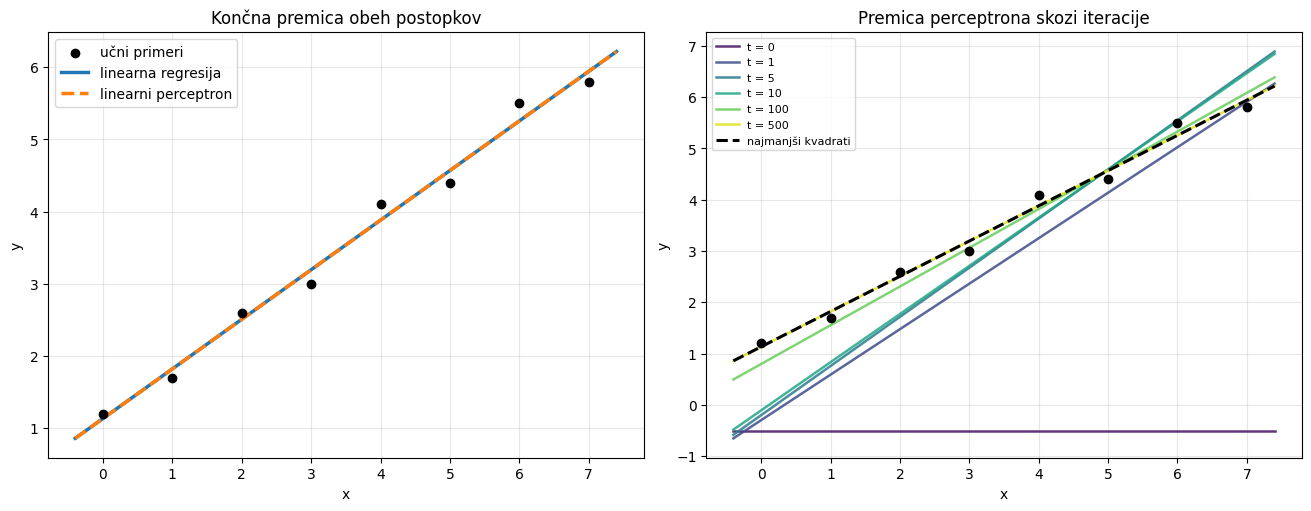

In [3]:
mreza_x = np.linspace(x.min() - 0.4, x.max() + 0.4, 200)
mreza_X = np.column_stack([np.ones_like(mreza_x), mreza_x])

fig, osi = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

osi[0].scatter(x, y, color="black", label="učni primeri", zorder=3)
osi[0].plot(mreza_x, mreza_X @ beta_nk, color="tab:blue", linewidth=2.5, label="linearna regresija")
osi[0].plot(
    mreza_x,
    mreza_X @ utezi_perceptron,
    color="tab:orange",
    linestyle="--",
    linewidth=2.5,
    label="linearni perceptron",
)
osi[0].set_title("Končna premica obeh postopkov")
osi[0].set_xlabel("x")
osi[0].set_ylabel("y")
osi[0].grid(alpha=0.3)
osi[0].legend()

barve = plt.cm.viridis(np.linspace(0.05, 0.95, len(zgodovina)))
osi[1].scatter(x, y, color="black", zorder=3)

for (iteracija, w), barva in zip(sorted(zgodovina.items()), barve):
    osi[1].plot(
        mreza_x,
        mreza_X @ w,
        color=barva,
        linewidth=1.8,
        alpha=0.85,
        label=f"t = {iteracija}",
    )
osi[1].plot(mreza_x, mreza_X @ beta_nk, color="black", linestyle="--", linewidth=2.2, label="najmanjši kvadrati")

osi[1].set_title("Premica perceptrona skozi iteracije")
osi[1].set_xlabel("x")
osi[1].set_ylabel("y")
osi[1].grid(alpha=0.3)
osi[1].legend(ncol=1, fontsize=8)

plt.show()

Na prvem grafu vidimo, da linearna regresija in linearni perceptron po dovolj iteracijah dobita praktično isto premico. To ni naključje: oba modela minimizirata isto kvadratno izgubo nad isto linearno obliko napovedi. Drugi graf prikaže učno dinamiko perceptrona. Začetna premica je daleč od podatkov, nato pa se skozi iteracije premika in vrti v smer, ki zmanjšuje povprečno kvadratno napako. 

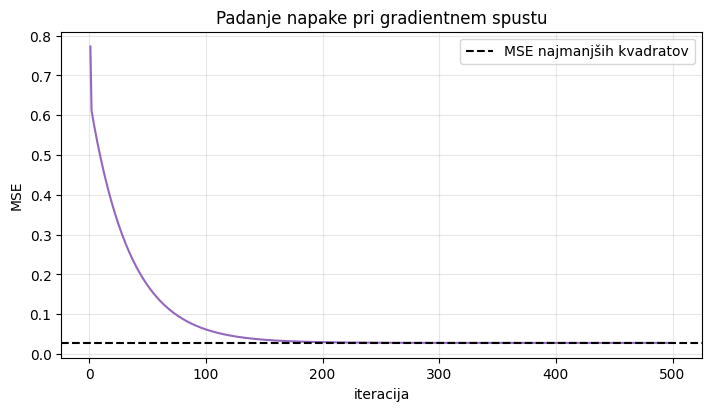

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)
ax.plot(np.arange(1, st_iteracij + 1), napake, color="tab:purple")
ax.axhline(mse_nk, color="black", linestyle="--", label="MSE najmanjših kvadratov")
ax.set_title("Padanje napake pri gradientnem spustu")
ax.set_xlabel("iteracija")
ax.set_ylabel("povprečna kvadratna napaka (MSE)")
ax.grid(alpha=0.3)
ax.legend()

plt.show()

Zgornji graf prikaže isto zgodbo prilagajanja premice učnim podatkom skozi vrednost napake: gradientni spust se postopoma približuje minimumu funkcije izgube (v tem primeru opazujemo povprečno kvadratno napako, _MSE_), ki ga normalne enačbe izračunajo neposredno.

## Gradientni spust in metoda najmanjših kvadratov

Primer pokaže, da se premica perceptrona pri dovolj dolgem učenju približa premici linearne regresije. To lahko pojasnimo tudi algebraično.

Pri paketnem gradientnem spustu za linearni perceptron uporabljamo iteracijo
$$
\boldsymbol{w}^{(t+1)}
= \boldsymbol{w}^{(t)} - \eta\frac{1}{n}X^T(X\boldsymbol{w}^{(t)} - \boldsymbol{y}).
$$
Če zaporedje uteži konvergira proti vektorju $\boldsymbol{w}^*$, se v limiti uteži ne spreminjajo več. Zato mora biti gradient v tej točki enak nič:
$$
\frac{1}{n}X^T(X\boldsymbol{w}^* - \boldsymbol{y}) = \boldsymbol{0}.
$$
Od tod sledi
$$
X^TX\boldsymbol{w}^* = X^T\boldsymbol{y}.
$$
To so iste normalne enačbe kot pri metodi najmanjših kvadratov. Če je matrika $X^TX$ obrnljiva, dobimo
$$
\boldsymbol{w}^* = (X^TX)^{-1}X^T\boldsymbol{y}.
$$

Linearni perceptron z linearno funkcijo aktivacije in kvadratno izgubo se torej v limiti nauči istega modela kot linearna regresija. Razlika je v poti do rešitve: metoda najmanjših kvadratov jo izračuna neposredno, gradientni spust pa se ji približuje iterativno. Hkrati je, kot bomo videli na naslednjem predavanju, gradientni spust bolj splošen učni algoritem, ki ga lahko uporabimo tudi takrat, ko nevronska mreža vključuje nelinearne funkcije aktivacije.

## Linearni perceptron za klasifikacijo z več razredi

Pri klasifikaciji ciljna spremenljivka ni numerična, temveč zavzame eno izmed $K$ diskretnih vrednosti iz domene ciljne spremenljivke $D_Y = \{c_1, c_2, \dots, c_K\}$. Za vsako vrednost ciljne spremenljivke iz njene domene uporabimo en izhodni nevron. Linearni del modela za primer $\boldsymbol{x}$ izračuna $K$ vrednosti, ki jim pravimo **logiti** ali **ocene verjetja vrednosti ciljne spremenljivke**:
$$
\boldsymbol{z} = W^T\boldsymbol{x},
$$
kjer je
$$
W = [\boldsymbol{w}_1, \boldsymbol{w}_2, \dots, \boldsymbol{w}_K] \in \mathbb{R}^{(p+1) \times K}
$$
matrika uteži na sinapsah nevronske mreže. Komponenta
$$
z_k = \boldsymbol{w}_k^T\boldsymbol{x}
$$
je linearna ocena verjetja za vrednost ciljne spremenljivke $c_k$.

Te ocene same po sebi še niso verjetnosti: lahko so negativne, lahko so večje od $1$, njihov seštevek pa ni nujno $1$. Zato v izhodni plasti nevronske mreže za klasifikacijo uporabimo normalizacijsko eksponentno funkcijo aktivacije, ki jo imenujemo **softmax**:
$$
\hat{p}_k = \operatorname{softmax}(\boldsymbol{z})_k
= \frac{e^{z_k}}{\sum_{l=1}^{K}e^{z_l}}.
$$
Velja
$$
\hat{p}_k > 0,
\qquad
\sum_{k=1}^{K}\hat{p}_k = 1,
$$
zato lahko $\hat{p}_k$ interpretiramo kot oceno verjetnosti $P(Y = c_k \mid X = \boldsymbol{x})$. Končna napoved je tako razred z največjo verjetnostjo:
$$
\hat{y} = \arg\max_{c_k \in D_Y} \hat{p}_k.
$$
Ker je softmax monotono odvisen od verjetij, je to enako kot izbira največjega verjetja $z_k$. Vendar nam softmax omogoča še pomembno verjetnostno interpretacijo izhodov in primerno funkcijo izgube, ki jo opišemo v nadaljevanju.

Za izračun funkcije izgube najprej ciljno spremenljivko zapišemo z vektorjem slamnatih spremenljivk (angl. _one hot_). Če je pravi razred $c_m$, potem je vektor enak
$$
\boldsymbol{y} = [0, \dots, 0, 1, 0, \dots, 0]^T,
$$
kjer je $y_m = 1$ in $y_k = 0$ za $k \ne m$. Spomnimo se, da nevronska mreža napove verjetnostno porazdelitev vrednosti ciljne spremenljivke, torej vektor
$$
\hat{\boldsymbol{p}} = [\hat{p}_1, \hat{p}_2, \dots, \hat{p}_K]^T.
$$
Naravna funkcija izgube, ki primerja ta dva vektorja, je **prečna entropija** med porazdelitvijo opazovanih vrednosti ciljne spremenljivke $\boldsymbol{y}$ in napovedano porazdelitvijo $\hat{\boldsymbol{p}}$:
$$
\mathcal{L}(\boldsymbol{y}, \hat{\boldsymbol{p}})
= -\sum_{k=1}^{K} y_k \log \hat{p}_k.
$$
Če je za opazovan primer prava vrednost ciljne spremenljivke enaka $c_m$, se zgornja vsota poenostavi v en sam njen člen
$$
\mathcal{L}(\boldsymbol{y}, \hat{\boldsymbol{p}})
= -\log \hat{p}_m.
$$
Izguba modela je torej odvisna od tega, kako majhno verjetnost je pripisal pravi (opazovani) vrednosti ciljne spremenljivke. Če model tej vrednosti pripiše verjetnost blizu $1$, je vrednost funkcije izgube blizu $0$. Če model tej vrednosti pripiše zelo majhno verjetnost, izguba močno naraste. Kar je pričakovano, izguba je torej najmanjša pri pravilni napovedi.

Pomembna opomba: Prečna entropija je definirana z logaritmom z osnovo $2$. V praksi pogosto uporabimo naravni logaritem. Razlika je le konstantni faktor $1 / \log 2$, zato se točka minimuma funkcije ne spremeni; spremeni se samo velikost gradienta.

Preverimo na koncu, kako izpeljemo formule za gradientni spust v tem primeru. Naj bo
$$
\hat{p}_k = \frac{e^{z_k}}{\sum_{r=1}^{K} e^{z_r}}.
$$
napovedana verjetnost, da je vrednost ciljne spremenljivke enaka $c_k$. Odvod funkcije aktivacije softmaxa po verjetnju $z_l$ je tako
$$
\frac{\partial \hat{p}_k}{\partial z_l}
= \hat{p}_k(\delta_{kl} - \hat{p}_l),
$$
kjer je $\delta_{kl}$ indikatorksa funkcija Kroneckerjeva delta:
$$
\delta_{kl} =
\left\{
\begin{array}{ll}
1, & k=l, \\
0, & k \ne l,
\end{array}
\right.
$$
ki vrne vrednost $1$, če sta indeksa $k$ in $l$ enaka in $0$ sicer. Zdaj izpeljimo gradient prečne entropije po verjetju $z_l$:
$$
\frac{\partial \mathcal{L}}{\partial z_l}
= \sum_{k=1}^{K}
\left(-\frac{y_k}{\hat{p}_k}\right)
\hat{p}_k(\delta_{kl} - \hat{p}_l)
= -\sum_{k=1}^{K} y_k\delta_{kl}
+ \sum_{k=1}^{K} y_k\hat{p}_l
= -y_l + \hat{p}_l\sum_{k=1}^{K} y_k.
$$

Ker je $\boldsymbol{y}$ vektor slamnatih spremenljivk z zgolj eno neničelno komponento, ki ima vrednost 1, velja $\sum_{k=1}^{K} y_k = 1$. Zato dobimo izjemno preprost rezultat:
$$
\frac{\partial \mathcal{L}}{\partial z_l} = \hat{p}_l - y_l.
$$

Za uteži razreda $c_l$ velja $z_l = \boldsymbol{w}_l^T\boldsymbol{x}$, zato je
$$
\frac{\partial z_l}{\partial \boldsymbol{w}_l} = \boldsymbol{x}.
$$
Gradient izgube po utežeh razreda $c_l$ je
$$
\frac{\partial \mathcal{L}}{\partial \boldsymbol{w}_l}
= (\hat{p}_l - y_l)\tilde{\boldsymbol{x}}.
$$

Opazimo podobnost z regresijskim perceptronom. Tudi tu je gradient sestavljen iz napake napovedi in vhodnega vektorja. Pri regresiji je napaka $\hat{y} - y$, pri klasifikaciji s softmaxom pa je napaka vektor $\hat{\boldsymbol{p}} - \boldsymbol{y}$. Zdaj, ko imamo gradient, lahko uporabimo gradientni spust za učenje uteži nevronske mreže.

# Naloga za bonus točke

V zapiskih za ta predavanja ni domače naloge za bonus točke.
<br/><br/>